# EDA - Customer Lifetime Value Analysis (CLV)

*Disclaimer: This project is for practice and educational purposes (Python data analysis). Share and Act section are AI-assisted.*

*Credit: https://github.com/M0hamedIbrahim1/Customer-Lifetime-Value-Analysis*

# Ask

*Goal: Define the problem and the questions we need to answer.*

## Objective
The primary objective of this analysis is to determine the long-term value of our customer base and optimize operational efficiency. We are moving from looking at "one-time sales" to understanding "customer relationships."

## Business Challenge
The company needs to identify which customers drive the most revenue to better allocate marketing budgets and manage inventory effectively to reduce cancellations.

## Key Analytical Questions
1. **Profitability:** What is the average Customer Lifetime Value (CLV), and who are our top-tier customers?
2. **Segmentation:** How can we group customers by purchase behavior and geographic location?
3. **Seasonality:** What are the monthly trends for sales, and why do certain months see spikes in cancellations?
4. **Operations:** How does stock availability and product description quality impact purchasing behavior?

# Prepare

*Goal: Data sourcing and initial environment setup.*

In [ ]:
# Import nescessary libraries for EDA

from pathlib import Path # Handling path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()

path_raw_data  = notebook_dir / '..' / 'data' / 'raw'  / 'df_raw.csv'
path_clean_data = notebook_dir / '..' / 'data' / 'clean' / 'df_clean.csv'

df_raw = pd.read_csv(path_raw_data, encoding="ISO-8859-1")

In [ ]:
df_clean = df_raw.copy()

# Clean the formatting
path_processed = notebook_dir / '..' / 'data' / 'processed' / 'data.csv'
path_processed.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(path_processed, index=False, encoding='utf-8')

In [15]:
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [16]:
# The shape of df_raw (rows and column)
df_raw.shape

(541909, 8)

Data has 541909 rows and 8 columns

# Process

*Goal: Data cleaning and transformation.*

## Missing data

In [17]:
df_raw.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing data
- `Description`: 1454
- `CustormerID`: 135080 or 24.93% missing value (135080 / 135080 * 100 = 24.93%)

The significance missing value of `CustomerID` could lead to data bias or noise. To keep this clean, we will remove them.

In [18]:
df_clean = df_clean[df_clean['CustomerID'].notna()]

In [19]:
# Check again after drop the null

df_clean.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Duplicated Data

In [20]:
df_clean.duplicated().sum()

np.int64(5225)

In [21]:
# Remove duplicate df_clean

df_clean.drop_duplicates(inplace=True)

## Converting Data type

In [22]:
df_clean.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

`InvoiceDate` is currently string. Need to convert into date. `CustomerID` suppose to be a whole number which mean integer

In [23]:
# Convert string to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [24]:
# Convert float to integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int, errors = 'ignore')

## Handle Cancelled transactions

In many e-commerce datasets, an InvoiceNo that starts with or is exactly 'C' represents a cancellation or a return.

In [25]:
# Filter out the 'C' which is 'Cancelled' order

df_clean = df_clean[df_clean['InvoiceNo'].apply(lambda x : x[0]) != 'C']

# Analzye

*Goal: Exploratory Data Analysis (EDA). Discovery and calculation.*

## Custormer Lifetime Value (CLV)

**CLV = ((Average Order Value x Purchase Frequency) / Churn Rate) x Profit Margin**

In [26]:
# Calculate total purchase

df_clean['total_purchase'] = df_clean['UnitPrice'] * df_clean['Quantity']

In [27]:
data_group = df_clean.groupby('CustomerID', as_index=False).agg({
  'total_purchase':'sum', 'InvoiceNo':'count', 'Country':'min', 'InvoiceDate':lambda date:(max(date) - min(date)).days}).rename(
    columns = {'InvoiceNo':'num_transactions', 'InvoiceDate':'days'}
  )

### 1. Calculate Average Order Value

In [28]:
data_group['avg_order_value'] = data_group['total_purchase'] / data_group['num_transactions']

In [29]:
data_group.head()

,CustomerID,total_purchase,num_transactions,Country,days,avg_order_value
0,12346,77183.60,1,United Kingdom,0,77183.600000
1,12347,4310.00,182,Iceland,365,23.681319
2,12348,1797.24,31,Finland,282,57.975484
3,12349,1757.55,73,Italy,0,24.076027
4,12350,334.40,17,Norway,0,19.670588


### 2. Calculate Purchase Frequency

In [30]:
purchase_frequency = sum(data_group['num_transactions']) / data_group.shape[0]

### 3. Calculate Repeat Rate and Churn Rate 

In [31]:
# Calculate Repeat Rate
repeat_rate = len(data_group[data_group['num_transactions'] >= 2]) / len(data_group)
round(repeat_rate * 100.0, 2)

98.34

The Percentage of Repeat Rate is `98.34%`

**Retention Churn (The "One-and-Done" Rate)**

*Churn Rate=1−Repeat Rate*

- When to use: Retail and E-commerce.
- What it tells you: "What percentage of my customers are 'One-Timers' who never came back?"

In [32]:
# Calculate Churn Rate
churn_rate = 1 - repeat_rate
round(churn_rate * 100.0, 2)

1.66

The Percentage of Churn Rate is `1.66%`

### 4. Calculate Profit Margin

Profit margin is the percentage of total sales that remains as profit. Assume our business has approximately 10% profit on the total sales

In [33]:
data_group['profit_margin'] = data_group['total_purchase'] * 0.1 

### 5. Calculate Custormer Lifetime Value (CLV)

In [34]:
churn_rate

0.016593685180917306

In [35]:
# CLV = ((Average Order Value x Purchase Frequency) / Churn Rate) x Profit Margin

data_group['CLV'] = (data_group['avg_order_value'] * purchase_frequency) / churn_rate
data_group['CLV'] = data_group['CLV'] * 0.10 # profit margin
data_group['CLV'] = data_group['CLV'].apply(lambda x: '{:.2f}'.format(x))

In [36]:
data_group.head()

,CustomerID,total_purchase,num_transactions,Country,days,avg_order_value,profit_margin,CLV
0,12346,77183.60,1,United Kingdom,0,77183.600000,7718.360,42100652.22
1,12347,4310.00,182,Iceland,365,23.681319,431.000,12917.24
2,12348,1797.24,31,Finland,282,57.975484,179.724,31623.37
3,12349,1757.55,73,Italy,0,24.076027,175.755,13132.54
4,12350,334.40,17,Norway,0,19.670588,33.440,10729.54


## Customer Segmentation

In [37]:
data_group_v1 = data_group

## Based on total purchase value

In [ ]:
data_group_v1 = data_group
data_group_v1['segment_purchase'] = pd.cut(data_group['total_purchase'], bins = [0, 1500, 3500, float('inf')], labels = ['Low Purchase', 'Medium Purchase', 'High Purchase'])

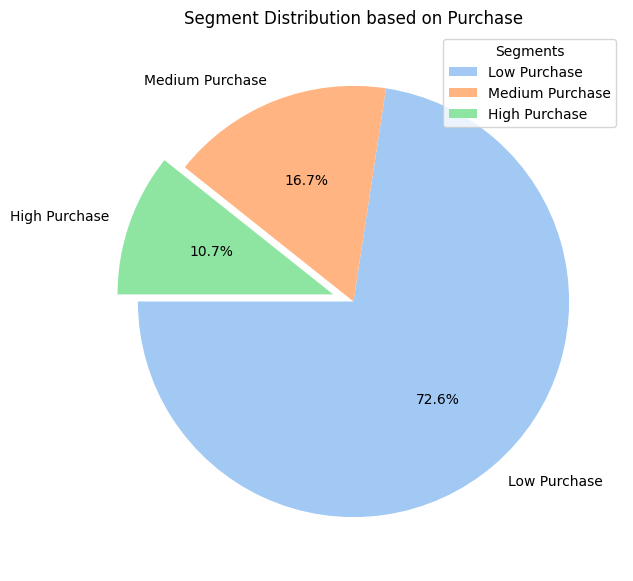

In [76]:
v1 = data_group_v1['segment_purchase'].value_counts()

colors = sns.color_palette('pastel')[0:3]
explode = [0, 0, 0.1]
plt.figure(figsize=(8, 7))
plt.pie(v1, labels=v1.index, colors=colors, autopct='%1.1f%%', startangle=180, explode=explode)
plt.title('Segment Distribution based on Purchase')
plt.legend(v1.index, title='Segments', loc='best')
plt.show()


## Customer with High Transactions

In [81]:
# Top 10 Customers

x = data_group[['CustomerID', 'num_transactions']].sort_values(by = 'num_transactions', ascending = [False]).head(10)

Text(0.5, 1.0, 'Top 10 Customers')

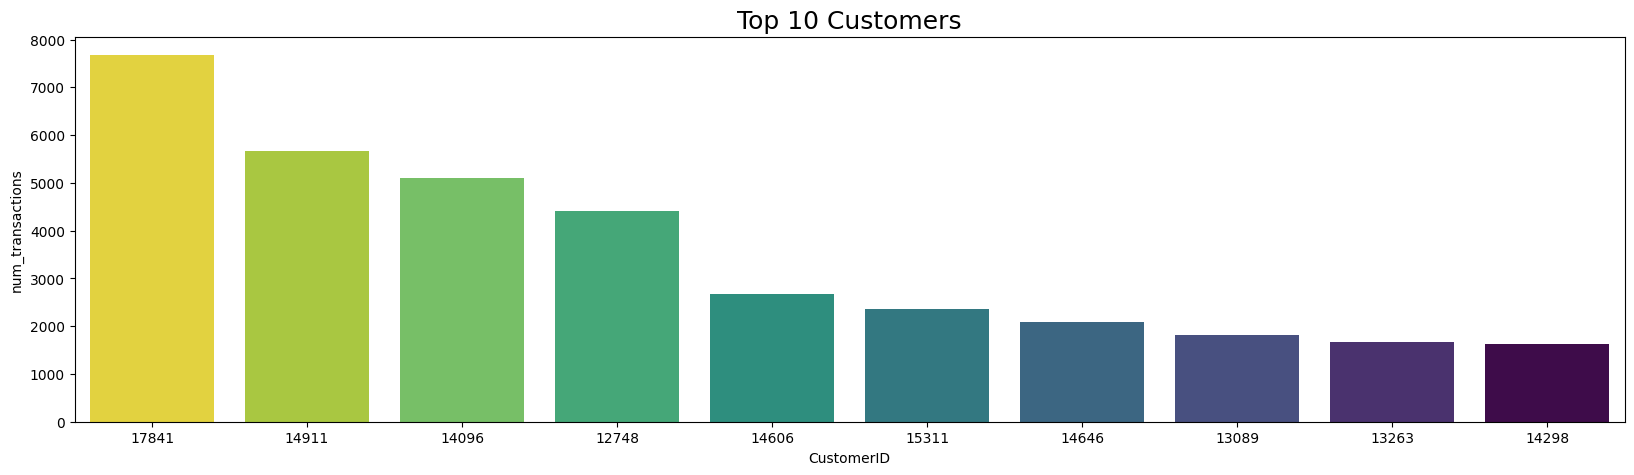

In [ ]:
plt.figure(figsize=(20, 5))

x['rank'] = range(len(x)) # Ordered the color by bar order
sns.barplot(
    data = x,
    x = 'CustomerID',
    y = 'num_transactions',
    order = x['CustomerID'],
    hue = 'rank',
    palette = 'viridis_r', # _r for reverse color palette
    legend =False
)
plt.title("Top 10 Customers", fontsize= 18)

## Geographic Analysis

### Top 10 Countries in Revenue by Purchase

In [88]:
data_group_v2 = data_group.groupby('Country', as_index= False).agg({
  'total_purchase':'sum', 'num_transactions':'sum'
  })

In [89]:
# Top 10 Countries

data_group_v2 = data_group_v2.sort_values(by = 'total_purchase', ascending = [False]).head(10)

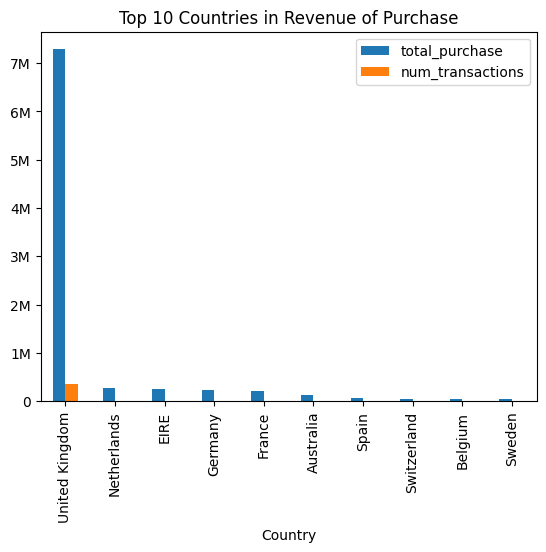

In [90]:
from matplotlib.ticker import FuncFormatter
data_group_v2.plot(kind = 'bar', x = 'Country')
def format_y_ticks(value, _):
    if value >= 1e6:
        return f'{int(value/1e6)}M'
    else:
        return int(value)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
plt.title('Top 10 Countries in Revenue of Purchase')
plt.show()

### Top 10 Countries with Most Customer

In [91]:
country = data_group['Country'].value_counts().reset_index(drop = False).head(10)
country

,Country,count
0,United Kingdom,3921
1,Germany,94
2,France,87
3,Spain,28
4,Belgium,24
5,Portugal,19
6,Switzerland,19
7,Italy,14
8,Finland,12
9,Austria,11


### Countries with High Cancelled Orders

In [92]:
df_cancel = pd.read_csv(path_raw_data, encoding='ISO-8859-1')
df_cancel = df_cancel[df_cancel['InvoiceNo'].apply(lambda x: x[0] == 'C')]
df_cancel['InvoiceDate'] = pd.to_datetime(df_cancel['InvoiceDate'])

In [ ]:
df_cancel_val = df_cancel['Country'].value_counts().nlargest(5)

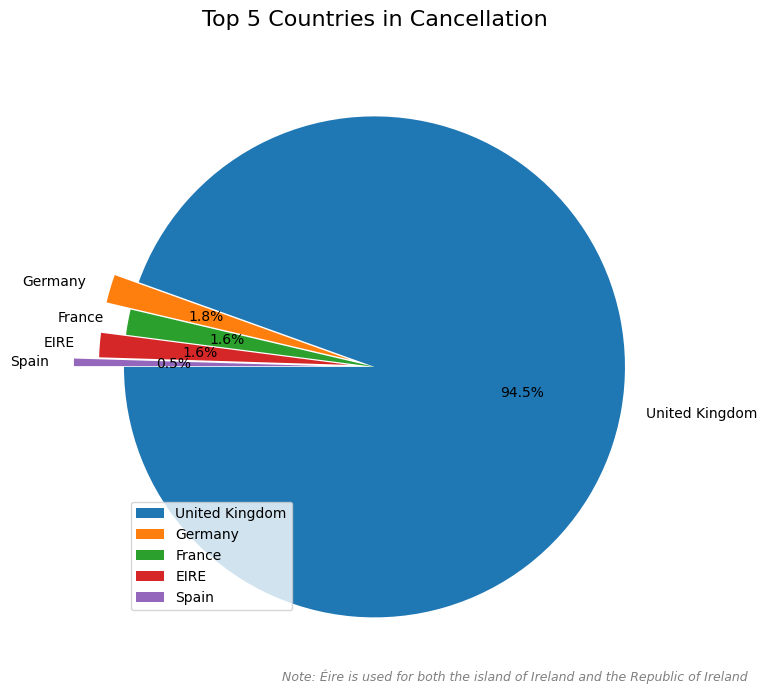

In [106]:
explode = [0, 0.1, 0, 0.1, 0.2]
colors = sns.color_palette('pastel')[0:4]

plt.figure(figsize=(8, 7))
plt.pie(df_cancel_val, labels = df_cancel_val.index, autopct ='%1.1f%%', startangle = 180, explode = explode)

plt.title('Top 5 Countries in Cancellation', fontsize = 16, pad = 20)
plt.legend(loc='lower left', bbox_to_anchor=(0.1, 0.1))

plt.figtext(0.95, 0.02, 
            'Note: Éire is used for both the island of Ireland and the Republic of Ireland', 
            horizontalalignment='right', 
            fontsize=9, 
            style='italic', 
            color='grey',
            wrap=True)

plt.tight_layout()
plt.show()

### Countries with Low Cancellation

In [105]:
df_cancel_val_low = df_cancel['Country'].value_counts().nsmallest(5)
df_cancel_val_low

Country
Saudi Arabia      10
Bahrain           19
Czech Republic    30
Brazil            32
Lithuania         35
Name: count, dtype: int64

## Time Series Analysis

### Patterns and Trends in Count of Orders

In [107]:
df_clean['InvoiceDate_d'] = df_clean['InvoiceDate'].dt.date

In [108]:
PurchaseDate_data = df_clean.groupby('InvoiceDate_d', as_index = False).agg({
  'InvoiceNo':'count', 'total_purchase':'sum'
})

<function matplotlib.pyplot.show(close=None, block=None)>

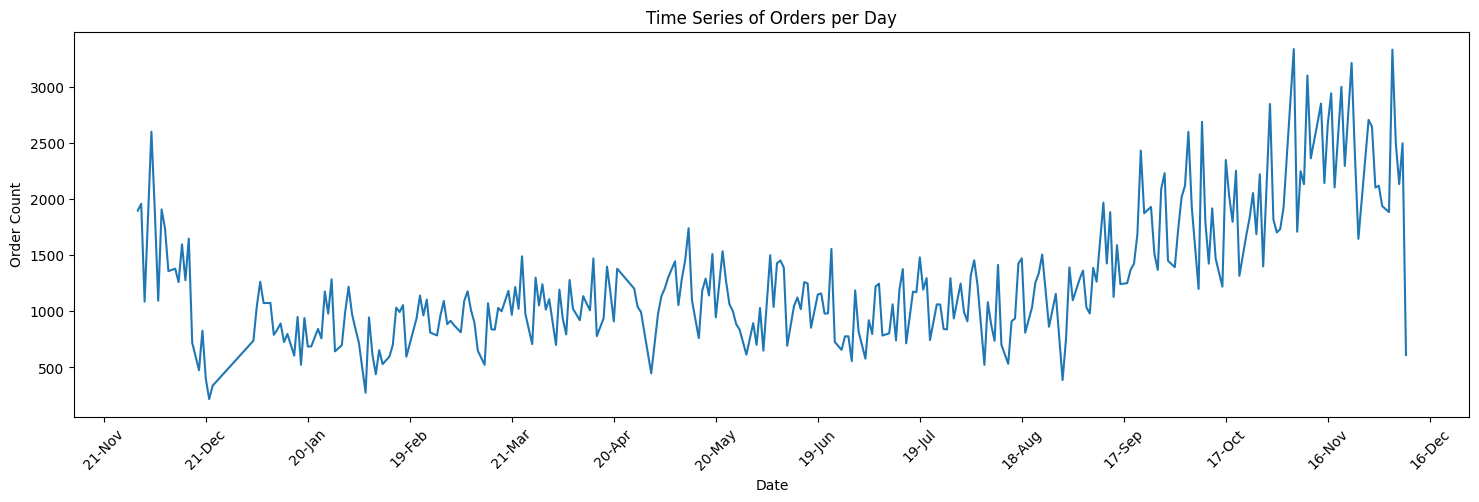

In [110]:
plt.figure(figsize = (18, 5))
sns.lineplot(data = PurchaseDate_data, x = 'InvoiceDate_d', y = 'InvoiceNo')

plt.title('Time Series of Orders per Day')
plt.xlabel('Date')
plt.ylabel('Order Count')

import matplotlib.dates as mdates
date_format = mdates.DateFormatter("%d-%b")
plt.gca().xaxis.set_major_formatter(date_format)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval = 30))
plt.xticks(rotation = 45)

plt.show

## Month vs Total Purchase

In [111]:
# Filter out the month from date
df_clean['month'] = df_clean['InvoiceDate'].dt.month_name() 
from calendar import calendar
import calendar
df_clean['month'] = pd.Categorical(df_clean['month'], categories = list(calendar.month_name)[1:])


In [112]:
month_data = df_clean.groupby('month', as_index = False)['total_purchase'].sum()
month_data

,month,total_purchase
0,January,568101.310
1,February,446084.920
2,March,594081.760
3,April,468374.331
4,May,677355.150
5,June,660046.050
6,July,598962.901
7,August,644051.040
8,September,950690.202
9,October,1035642.450


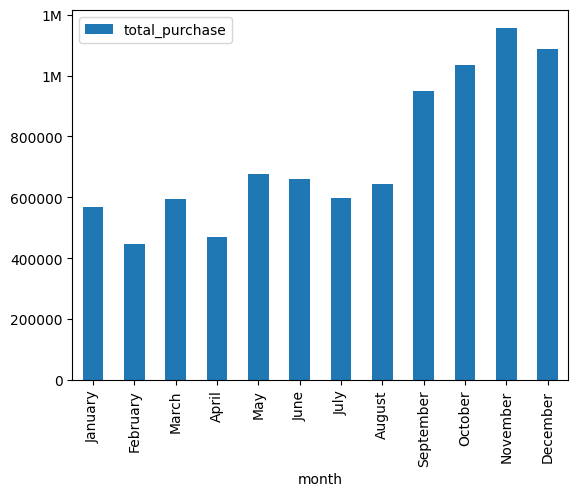

In [ ]:
# Plot the graph of Month vs Total Purchase

month_data.plot(kind = 'bar', x = 'month')
from matplotlib.ticker import FuncFormatter

def format_y_ticks(value, _):
    if value >= 1e6:
        return f'{int(value/1e6)}M'
    else:
        return int(value)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
plt.title('Month with High Total Purchase')
plt.show()

## Month with High Cancellation Orders

In [118]:
df_cancel['InvoiceDate'] = pd.to_datetime(df_cancel['InvoiceDate'], errors = 'coerce')
df_cancel['month'] = df_cancel['InvoiceDate'].dt.month_name()

In [119]:
month_order = list(calendar.month_name)[1:]
df_cancel['month'] = pd.Categorical(df_cancel['month'], categories=month_order, ordered=True)

In [137]:
data_month_cancel = df_cancel.groupby('month', as_index = False)['InvoiceNo'].count()

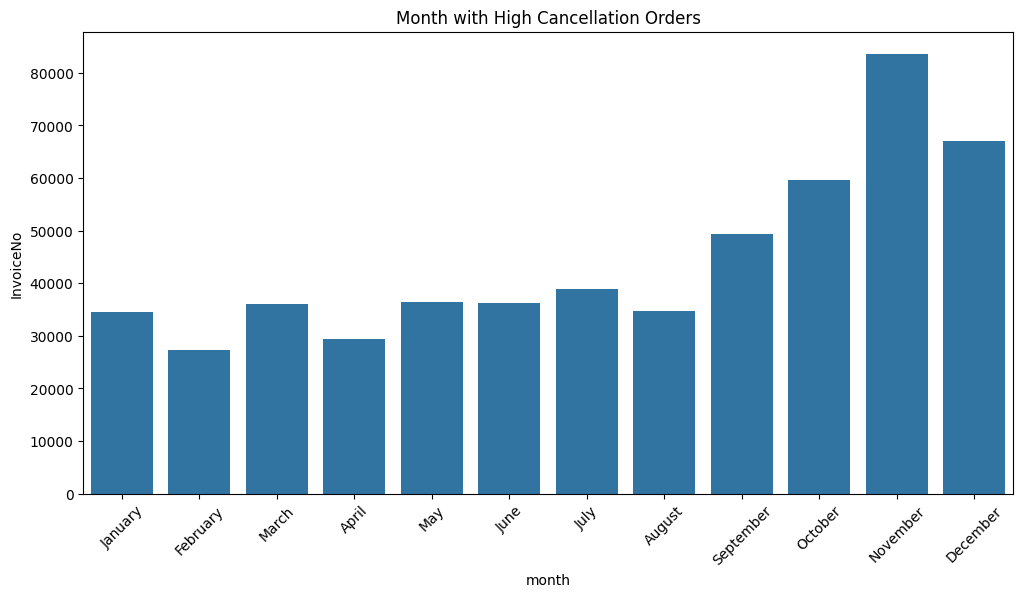

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=data_month_cancel, 
    x='month', 
    y='InvoiceNo'
)
plt.title('Month with High Cancellation Orders')
plt.xticks(rotation=45)
plt.show()

## Stock Analysis

### Top 10 Stocks with High Orders

Text(0.5, 1.0, 'Top 10 Stocks with High Orders')

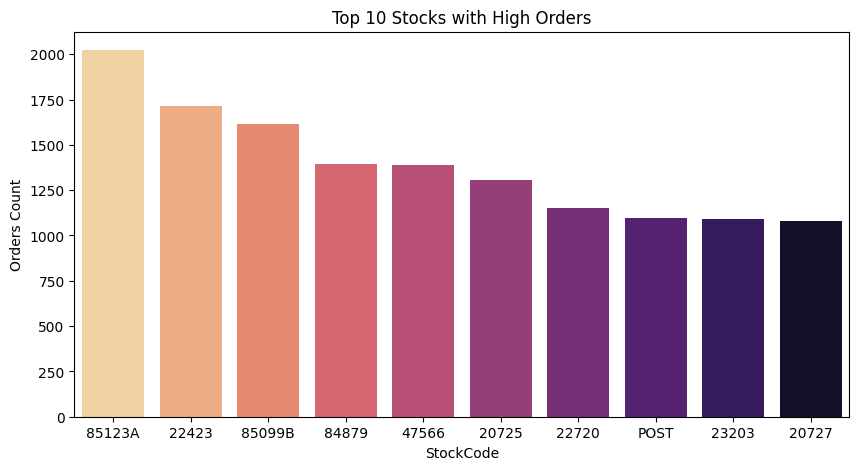

In [156]:
stockcode_counts = df_clean.StockCode.value_counts().sort_values(ascending = False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(
  x = stockcode_counts.index,
  y = stockcode_counts.values,
  hue = stockcode_counts.index,
  palette = 'magma_r',
  legend = False
  )
plt.ylabel('Orders Count')
plt.title('Top 10 Stocks with High Orders')

## Description Analysis

In [141]:
# Amount of unique descriptions

df_clean['Description'].nunique()

3877

### Most Common Description

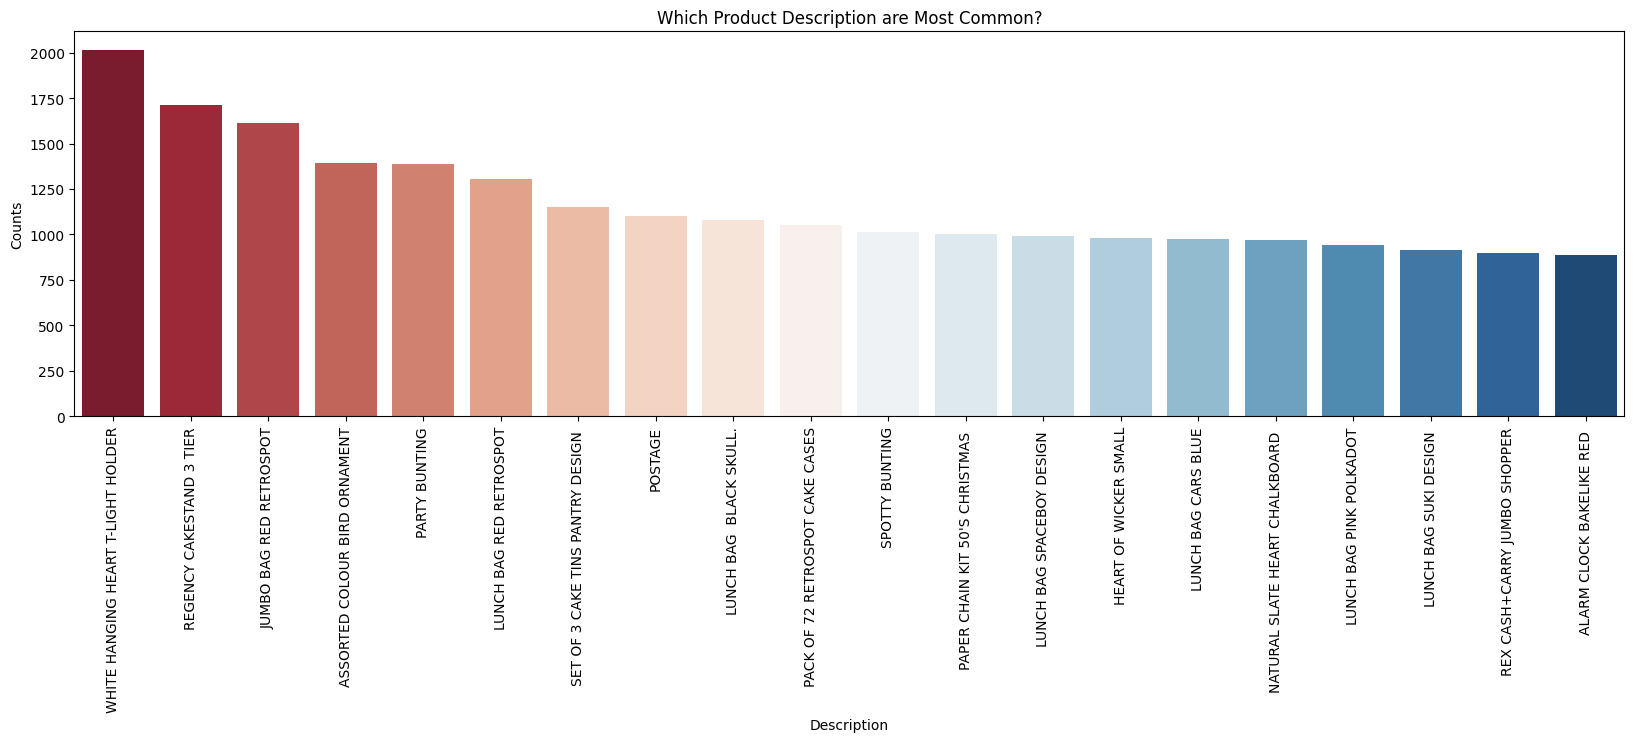

In [144]:
description_counts = df_clean.Description.value_counts().sort_values(ascending = False).head(20)
plt.figure(figsize = (20, 5))
sns.barplot(
  x = description_counts.index, 
  y = description_counts.values, 
  palette = 'RdBu',
  hue = description_counts.index,
  legend = False
  )
plt.ylabel('Counts')
plt.title('Which Product Description are Most Common?')
plt.xticks(rotation = 90)
plt.show()

### Which Product has the Highest Sales?

In [145]:
df_clean['total'] = df_clean['UnitPrice'] * df_clean['Quantity']

Text(0, 0.5, 'Product Description')

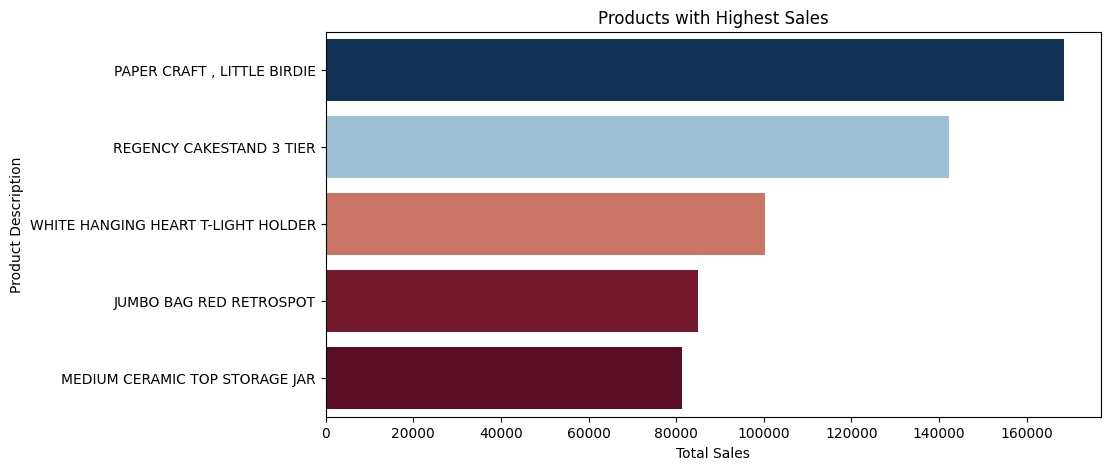

In [149]:
product_sales= df_clean.groupby('Description').agg({'total' : 'sum'}).sort_values(by = 'total' , ascending = False).reset_index(drop= False).head(5)

plt.figure(figsize = (10,5))
ad = sns.barplot(
  y = 'Description', 
  x = 'total',
  hue = 'total',
  data = product_sales,
  palette = 'RdBu',
  legend = False
  )

plt.title('Products with Highest Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Description')

# Share

*Goal: Communication of findings.*

## I. Strategic Sales Drivers (What is Winning?)

### Products with the Highest Sales Volume
Our data reveals a distinct hierarchy in our product catalog. While we have thousands of unique items, our revenue engine is powered by a small "Top Tier" of products.



### Key Takeaway:
The **"PAPER CRAFT",** **"LITTLE BIRDIE"** and **"REGENCY CAKESTAND"** are not just popular; they are our primary high-margin drivers. Marketing should prioritize advertising spend on these specific SKUs to maximize Return on Ad Spend (ROAS).


Text(0, 0.5, 'Product Description')

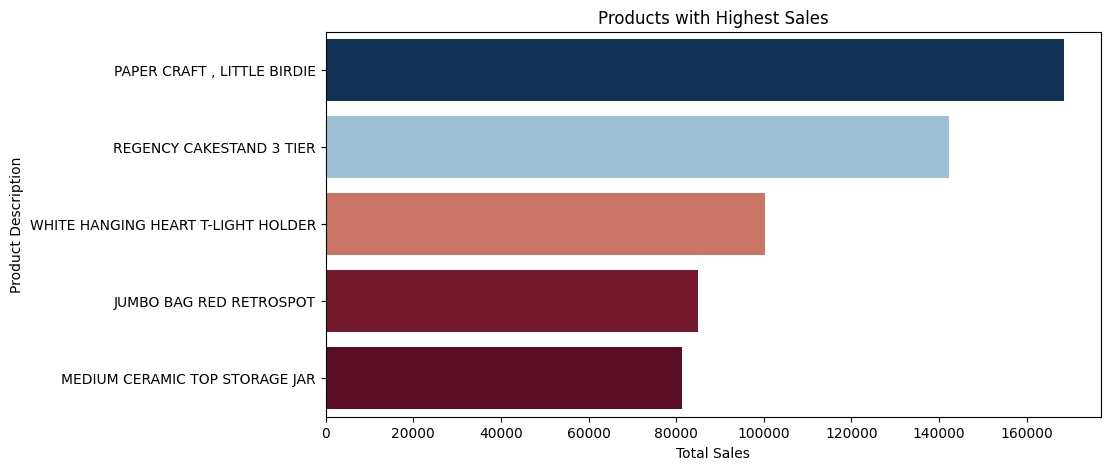

In [157]:
product_sales= df_clean.groupby('Description').agg({'total' : 'sum'}).sort_values(by = 'total' , ascending = False).reset_index(drop= False).head(5)

plt.figure(figsize = (10,5))
ad = sns.barplot(
  y = 'Description', 
  x = 'total',
  hue = 'total',
  data = product_sales,
  palette = 'RdBu',
  legend = False
  )

plt.title('Products with Highest Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Description')

## II. Operational Risk Management (Where are we losing money?)

### Revenue Hotspots & Cancellation Leaks
The overwhelming majority of our customer base (94.5%) is in the UK. However, even with this massive volume, the "long tail" of international sales is leaking profit.

#### Key Takeaway:
Portugal and Ireland show disproportionately high cancellation rates that cannot be explained by UK volume alone. This indicates localized shipping delays, customs issues, or payment processing glitches that must be investigated by Logistics immediately.

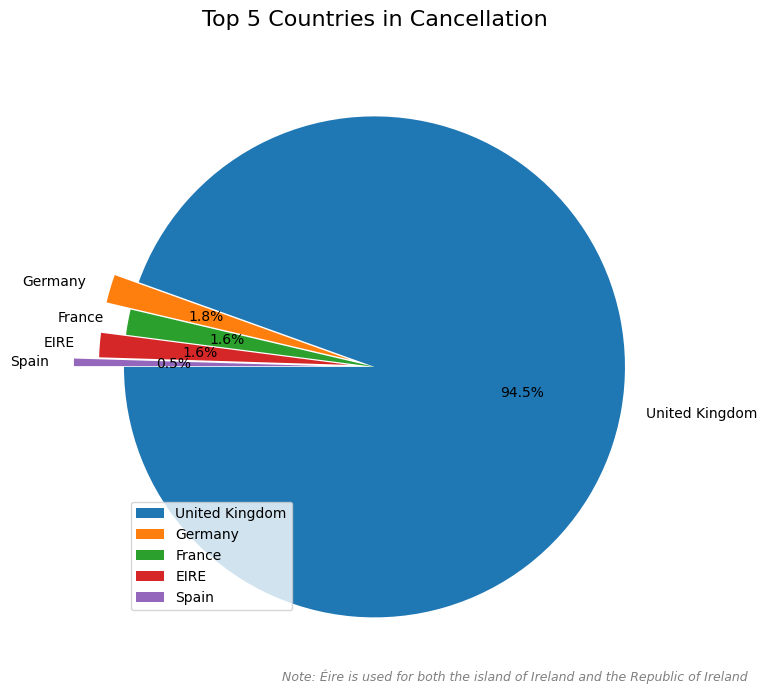

In [158]:
explode = [0, 0.1, 0, 0.1, 0.2]
colors = sns.color_palette('pastel')[0:4]

plt.figure(figsize=(8, 7))
plt.pie(df_cancel_val, labels = df_cancel_val.index, autopct ='%1.1f%%', startangle = 180, explode = explode)

plt.title('Top 5 Countries in Cancellation', fontsize = 16, pad = 20)
plt.legend(loc='lower left', bbox_to_anchor=(0.1, 0.1))

plt.figtext(0.95, 0.02, 
            'Note: Éire is used for both the island of Ireland and the Republic of Ireland', 
            horizontalalignment='right', 
            fontsize=9, 
            style='italic', 
            color='grey',
            wrap=True)

plt.tight_layout()
plt.show()

## III. Seasonality & Prevention Strategy (When is the system strained?)

### High Sales Volume vs. High Cancellation Spike
Our Time Series Analysis confirmed that sales are highly seasonal. The combined data from our "Month vs. Sales" and "Month with High Cancellation" charts tells a crucial story about our systems during peak stress.

#### Key Takeaway:
Sales peak aggressively in November/December. However, this same period sees our highest cancellation rates, indicating operational strain. We must implement better stock forecasting and fulfillment capacity checks during the Q4 "Holiday Strain" to recover an estimated 3-5% in lost revenue caused by these avoidable returns.

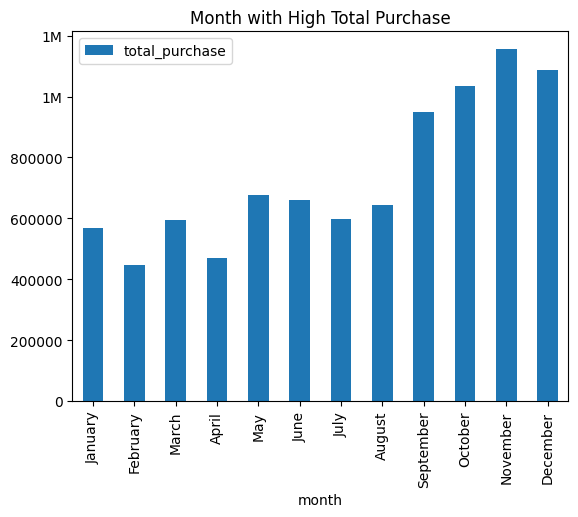

In [159]:
# Plot the graph of Month vs Total Purchase

month_data.plot(kind = 'bar', x = 'month')
from matplotlib.ticker import FuncFormatter

def format_y_ticks(value, _):
    if value >= 1e6:
        return f'{int(value/1e6)}M'
    else:
        return int(value)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
plt.title('Month with High Total Purchase')
plt.show()

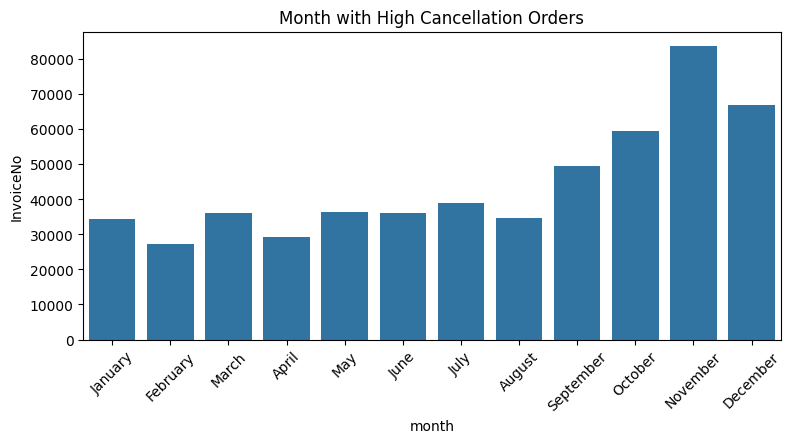

In [162]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=data_month_cancel, 
    x='month', 
    y='InvoiceNo'
)
plt.title('Month with High Cancellation Orders')
plt.xticks(rotation=45)
plt.show()

# Act

*Goal: Recommendations and next steps.*

## 1. High-Value Customer Retention Strategy
**Finding:** Our analysis identified a core group of "High-Value" customers (Top 10) who generate a disproportionate amount of revenue.

*   **Action:** Launch a **VIP Loyalty Program** specifically targeting the "Platinum" segment identified in the analysis. 
*   **Tactics:** Offer early access to new "Regency" and "Heart" product lines and provide exclusive volume-based discounts.
*   **Expected Impact:** Increasing retention in this segment by just 0.5% will significantly boost overall annual revenue due to their high CLV.

## 2. Supply Chain & Logistics Optimization
**Finding:** While the UK is the primary market, Ireland and Portugal show significantly higher cancellation rates, specifically during the Q4 peak.

*   **Action:** Conduct a **Logistics Audit** for international fulfillment.
*   **Tactics:** 
    *   Investigate the "Dublin and Lisbon Leaks" to see if cancellations are due to customs delays or high shipping costs.
    *   Consider localized warehousing or a different courier partner for these specific regions.
    *   Implement "Fulfillment Health Checks" starting in October to prepare for the November/December sales spike.

## 3. Product Content & SEO Overhaul
**Finding:** Products with descriptions containing keywords like "VINTAGE," "RETRO," and "HEART" outperform others in both volume and sales value.

*   **Action:** Implement an **A/B Testing Content Strategy** for product listings.
*   **Tactics:** 
    *   Rewrite descriptions for the bottom 20% of selling products to include high-converting emotional keywords identified in the "Description Analysis."
    *   Update SEO metadata for "Regency Cakestand" and "Paper Craft" items to double down on their current market lead.

## 4. Resource & Budget Reallocation
**Finding:** Marketing spend is currently distributed evenly, but CLV varies 5x between segments.

*   **Action:** Adopt a **CLV-Based Marketing Budget**.
*   **Tactics:** 
    *   Shift 15% of the acquisition budget from "Low-Value" geographic regions toward "Lookalike" audiences modeled after our "High-Value" UK and German customers.
    *   Set the maximum Customer Acquisition Cost (CAC) based on the calculated CLV tiers to ensure long-term profitability.

---

## Next Steps for Continuous Improvement
To ensure these actions are effective, we will:
1.  **Monitor Churn:** Track the 1.66% churn rate monthly to see if the VIP program lowers it.
2.  **Dashboard Integration:** Move this Python-based analysis into a live PowerBI or Tableau dashboard for real-time monitoring.
3.  **Feedback Loop:** Meet with the Logistics team in 90 days to review if the cancellation rate in Portugal/Ireland has decreased following the fulfillment audit.